# Notebook 1.3 — Price Spike Autopsy

Reconstruct the South Australia price spike on **2026-01-26** using the cached dispatch tables. The notebook is structured as an event autopsy: price path, regional balance, interconnector behaviour, generator response, then a short trader-style briefing.

Target window: **2026-01-25 00:00** to **2026-01-27 00:00**.

**Required `import_nem_data.py` command:**
```bash
uv run import_nem_data.py --start 2025/01/01 --end 2026/02/28 --dispatchprice --dispatchregionsum --dispatch-scada --dudetailsummary
```

**Also required:**
- `DISPATCHINTERCONNECTORRES` for the same cache span. `import_nem_data.py` does **not** currently expose a flag for this table, so populate it separately with:
```bash
python3 -c "
from nemosis import cache_compiler
cache_compiler('2025/01/01 00:00:00', '2026/02/28 23:55:00',
               'DISPATCHINTERCONNECTORRES', './data/nemosis_cache', fformat='parquet')
"
```
- Save the AEMO registration workbook `NEM Registration and Exemption List.xlsx` in `data/nemosis_cache/`.


In [3]:
from pathlib import Path
from textwrap import dedent

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
from IPython.display import Markdown, display

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

PROJECT_ROOT = Path.cwd().parent
CACHE_DIR = PROJECT_ROOT / 'data' / 'nemosis_cache'
REGISTRATION_PATH = CACHE_DIR / 'NEM Registration and Exemption List.xlsx'
TS_FORMAT = '%Y/%m/%d %H:%M:%S'

EVENT_START = pl.datetime(2026, 1, 25, 0, 0)
EVENT_END = pl.datetime(2026, 1, 27, 0, 0)
SPIKE_DAY_START = pl.datetime(2026, 1, 26, 0, 0)
SPIKE_DAY_END = pl.datetime(2026, 1, 27, 0, 0)
SPIKE_THRESHOLD = 300.0
EXTREME_THRESHOLD = 5000.0
MPC = 15100.0
SA_REGION = 'SA1'
VIC_REGION = 'VIC1'


In [4]:
def cache_files(table_name: str) -> list[str]:
    pattern = f'PUBLIC_*#{table_name}#FILE01#*.parquet'
    files = sorted(CACHE_DIR.glob(pattern))
    if not files:
        raise FileNotFoundError(f'No parquet files found for {table_name} under {CACHE_DIR}')
    return [str(path) for path in files]


def with_interval_end(lf: pl.LazyFrame) -> pl.LazyFrame:
    return lf.with_columns(
        pl.col('SETTLEMENTDATE').str.strptime(pl.Datetime, format=TS_FORMAT).alias('interval_end')
    )


def read_registration() -> pl.DataFrame:
    reg_pd = pd.read_excel(
        REGISTRATION_PATH,
        sheet_name='PU and Scheduled Loads',
        usecols=[
            'DUID',
            'Participant',
            'Station Name',
            'Region',
            'Fuel Source - Primary',
            'Technology Type - Primary',
        ],
    ).fillna('')
    for column in reg_pd.columns:
        reg_pd[column] = reg_pd[column].astype(str)
    return (
        pl.DataFrame(reg_pd)
        .rename({
            'Participant': 'participant',
            'Station Name': 'station_name',
            'Region': 'registration_region',
            'Fuel Source - Primary': 'fuel_primary',
            'Technology Type - Primary': 'technology_primary',
        })
        .unique(subset=['DUID'])
    )


registration = read_registration()
registration.head()


participant,station_name,registration_region,fuel_primary,technology_primary,DUID
str,str,str,str,str,str
"""Diamond Energy Pty Ltd""","""Oakey 1 Solar Farm""","""QLD1""","""Solar""","""Renewable""","""OAKEY1SF"""
"""HWF 2 Pty Ltd""","""Hornsdale Wind Farm 2""","""SA1""","""Wind""","""Renewable""","""HDWF2"""
"""Pacific Hydro Crowlands Pty Lt…","""Crowlands Wind Farm""","""VIC1""","""Wind""","""Renewable""","""CROWLWF1"""
"""Stanwell Corporation Limited""","""Tarong Power Station""","""QLD1""","""Fossil""","""Combustion""","""TARONG#3"""
"""South Australian Water Corpora…","""Adelaide Desalination Plant""","""SA1""","""Solar""","""Renewable""","""ADPPV3"""


## Load the Event Window

The notebook scans the full parquet cache lazily, applies the 48-hour filter immediately, then collects compact in-memory DataFrames for the event analysis.


In [5]:
price = (
    with_interval_end(pl.scan_parquet(cache_files('DISPATCHPRICE')))
    .filter(
        pl.col('interval_end').is_between(EVENT_START, EVENT_END, closed='left')
        & pl.col('REGIONID').is_in([SA_REGION, VIC_REGION])
        & (pl.col('INTERVENTION') == 0)
    )
    .select(['interval_end', 'REGIONID', 'RRP'])
    .collect()
    .sort(['interval_end', 'REGIONID'])
)

regionsum = (
    with_interval_end(pl.scan_parquet(cache_files('DISPATCHREGIONSUM')))
    .filter(
        pl.col('interval_end').is_between(EVENT_START, EVENT_END, closed='left')
        & (pl.col('REGIONID') == SA_REGION)
        & (pl.col('INTERVENTION') == 0)
    )
    .select([
        'interval_end',
        'TOTALDEMAND',
        'CLEAREDSUPPLY',
        'UIGF',
        'NETINTERCHANGE',
        'TOTALINTERMITTENTGENERATION',
    ])
    .collect()
    .sort('interval_end')
)

interconnector = (
    with_interval_end(pl.scan_parquet(cache_files('DISPATCHINTERCONNECTORRES')))
    .filter(
        pl.col('interval_end').is_between(EVENT_START, EVENT_END, closed='left')
        & pl.col('INTERCONNECTORID').is_in(['V-SA', 'V-S-MNSP1'])
        & (pl.col('INTERVENTION') == 0)
    )
    .select(['interval_end', 'INTERCONNECTORID', 'MWFLOW', 'METEREDMWFLOW'])
    .collect()
    .sort(['interval_end', 'INTERCONNECTORID'])
)

scada = (
    with_interval_end(pl.scan_parquet(cache_files('DISPATCH_UNIT_SCADA')))
    .filter(pl.col('interval_end').is_between(EVENT_START, EVENT_END, closed='left'))
    .select(['interval_end', 'DUID', 'SCADAVALUE'])
)

dds = (
    pl.scan_parquet(cache_files('DUDETAILSUMMARY'))
    .with_columns([
        pl.col('START_DATE').str.strptime(pl.Datetime, format=TS_FORMAT, strict=False).alias('start_dt'),
        pl.col('END_DATE').str.strptime(pl.Datetime, format=TS_FORMAT, strict=False).alias('end_dt'),
    ])
    .filter(
        (pl.col('REGIONID') == SA_REGION)
        & (pl.col('start_dt') <= EVENT_END)
        & (pl.col('end_dt').is_null() | (pl.col('end_dt') >= EVENT_START))
    )
    .select(['DUID', 'REGIONID', 'STATIONID'])
    .unique()
    .collect()
)

sa_scada = (
    scada.collect()
    .join(dds, on='DUID', how='inner')
    .join(registration, on='DUID', how='left')
    .with_columns([
        pl.col('fuel_primary').fill_null('Unknown'),
        pl.col('technology_primary').fill_null('Unknown'),
        pl.col('station_name').fill_null(pl.col('STATIONID')),
    ])
    .sort(['interval_end', 'DUID'])
)

price_wide = (
    price.pivot(index='interval_end', on='REGIONID', values='RRP')
    .sort('interval_end')
    .with_columns((pl.col(SA_REGION) - pl.col(VIC_REGION)).alias('sa_vic_spread'))
)

price_spikes = (
    price.filter(pl.col('REGIONID') == SA_REGION)
    .with_columns([
        (pl.col('RRP') > SPIKE_THRESHOLD).alias('over_300'),
        (pl.col('RRP') > EXTREME_THRESHOLD).alias('over_5k'),
    ])
    .sort('interval_end')
)

print('Loaded rows')
print(f"price:         {price.height:,}")
print(f"regionsum:     {regionsum.height:,}")
print(f"interconnector:{interconnector.height:,}")
print(f"sa_scada:      {sa_scada.height:,}")


Loaded rows
price:         1,152
regionsum:     576
interconnector:1,152
sa_scada:      52,416


In [6]:
sa_price = price.filter(pl.col('REGIONID') == SA_REGION).sort('interval_end')
peak_row = sa_price.sort('RRP', descending=True).row(0, named=True)

over_5k = sa_price.with_columns((pl.col('RRP') > EXTREME_THRESHOLD).alias('over_5k'))
runs = []
in_run = False
run_start = None
run_end = None
run_count = 0

for row in over_5k.iter_rows(named=True):
    ts = row['interval_end']
    flag = row['over_5k']
    if flag and not in_run:
        in_run = True
        run_start = ts
        run_count = 1
    elif flag and in_run:
        run_count += 1
    elif (not flag) and in_run:
        runs.append({'start': run_start, 'end': run_end, 'intervals': run_count})
        in_run = False
    run_end = ts

if in_run:
    runs.append({'start': run_start, 'end': run_end, 'intervals': run_count})

longest_run = max(runs, key=lambda item: item['intervals'])

spike_window = price_wide.filter(
    pl.col('interval_end').is_between(longest_run['start'], longest_run['end'], closed='both')
)
demand_window = regionsum.filter(
    pl.col('interval_end').is_between(longest_run['start'], longest_run['end'], closed='both')
)
interconnector_window = interconnector.filter(
    pl.col('interval_end').is_between(longest_run['start'], longest_run['end'], closed='both')
)

event_summary = {
    'peak_price': float(peak_row['RRP']),
    'peak_time': peak_row['interval_end'],
    'intervals_over_300': int(sa_price.filter(pl.col('RRP') > SPIKE_THRESHOLD).height),
    'intervals_over_5k': int(sa_price.filter(pl.col('RRP') > EXTREME_THRESHOLD).height),
    'longest_over_5k_start': longest_run['start'],
    'longest_over_5k_end': longest_run['end'],
    'longest_over_5k_intervals': longest_run['intervals'],
    'max_spread': float(price_wide.select(pl.max('sa_vic_spread')).item()),
    'vic_peak_during_run': float(spike_window.select(pl.max(VIC_REGION)).item()),
    'sa_demand_peak_during_run': float(demand_window.select(pl.max('TOTALDEMAND')).item()),
    'sa_supply_peak_during_run': float(demand_window.select(pl.max('CLEAREDSUPPLY')).item()),
    'min_net_interchange_during_run': float(demand_window.select(pl.min('NETINTERCHANGE')).item()),
    'v_sa_min_flow_during_run': float(
        interconnector_window.filter(pl.col('INTERCONNECTORID') == 'V-SA').select(pl.min('MWFLOW')).item()
    ),
    'v_sa_max_flow_during_run': float(
        interconnector_window.filter(pl.col('INTERCONNECTORID') == 'V-SA').select(pl.max('MWFLOW')).item()
    ),
}

pd.Series(event_summary)


peak_price                                    20300.0
peak_time                         2026-01-26 20:40:00
intervals_over_300                                 84
intervals_over_5k                                  36
longest_over_5k_start             2026-01-26 19:00:00
longest_over_5k_end               2026-01-26 21:40:00
longest_over_5k_intervals                          33
max_spread                                   20211.01
vic_peak_during_run                         437.37799
sa_demand_peak_during_run                     3140.33
sa_supply_peak_during_run                     3147.62
min_net_interchange_during_run                -532.46
v_sa_min_flow_during_run                    456.89497
v_sa_max_flow_during_run                    534.94222
dtype: object

## Panel 1: The Price Event in Context

SA1 and VIC1 prices are plotted over the full 48-hour window. The orange shading marks all SA intervals above $300/MWh, while the dashed red line shows the market price cap reference used in the notebook spec.


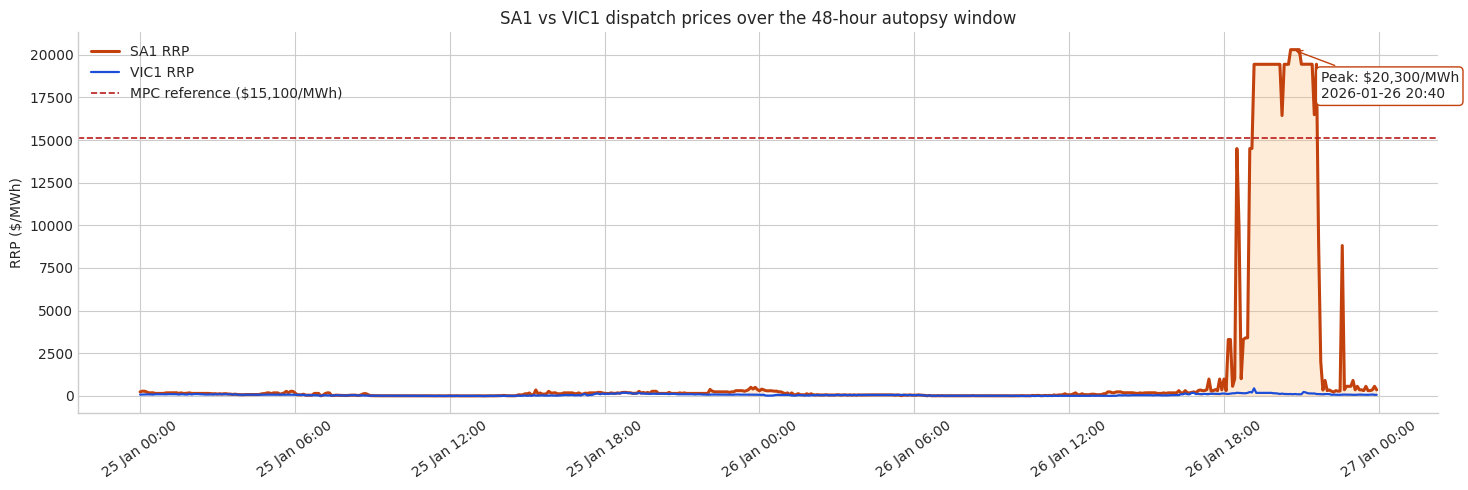

In [7]:
panel1 = price_wide.to_pandas()
sa_mask = panel1[SA_REGION] > SPIKE_THRESHOLD

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(panel1['interval_end'], panel1[SA_REGION], label='SA1 RRP', color='#c2410c', linewidth=2.2)
ax.plot(panel1['interval_end'], panel1[VIC_REGION], label='VIC1 RRP', color='#1d4ed8', linewidth=1.6)
ax.axhline(MPC, color='#b91c1c', linestyle='--', linewidth=1.2, label='MPC reference ($15,100/MWh)')
ax.fill_between(panel1['interval_end'], 0, panel1[SA_REGION], where=sa_mask, color='#fdba74', alpha=0.28)
ax.annotate(
    f"Peak: ${event_summary['peak_price']:,.0f}/MWh\n{event_summary['peak_time']:%Y-%m-%d %H:%M}",
    xy=(event_summary['peak_time'], event_summary['peak_price']),
    xytext=(20, -35),
    textcoords='offset points',
    bbox={'boxstyle': 'round,pad=0.3', 'fc': 'white', 'ec': '#c2410c'},
    arrowprops={'arrowstyle': '->', 'color': '#c2410c'},
)
ax.set_title('SA1 vs VIC1 dispatch prices over the 48-hour autopsy window')
ax.set_ylabel('RRP ($/MWh)')
ax.legend(loc='upper left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %H:%M'))
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()


## Panel 2: Demand and Supply Context

`DISPATCHREGIONSUM` gives the regional balance view: total demand, cleared supply, UIGF, and net interchange. The second panel shows the gap between cleared supply and UIGF, which is a useful shorthand for how much non-intermittent supply had to carry the region once solar faded.


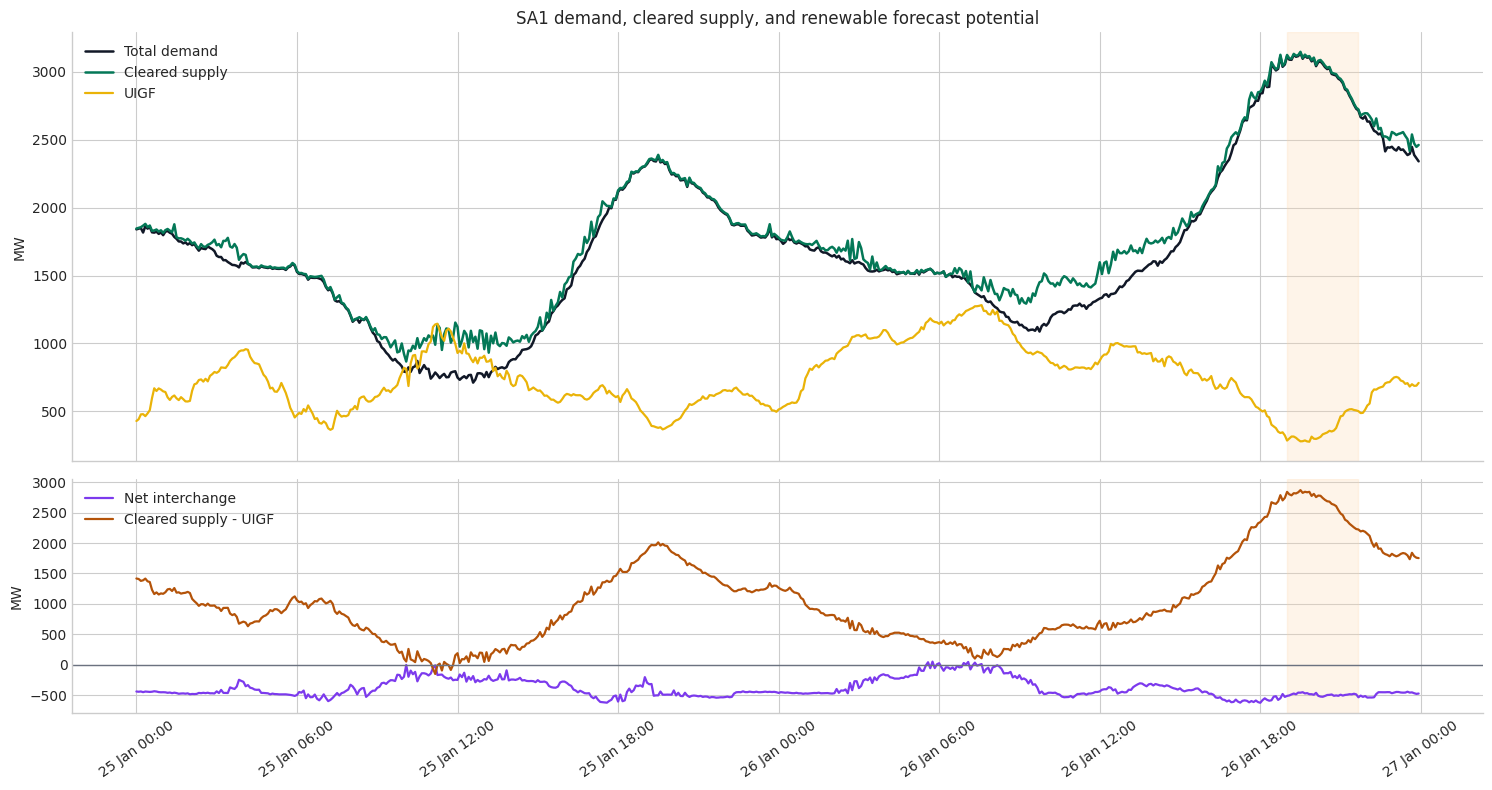

In [8]:
panel2 = regionsum.to_pandas()
panel2['non_uigf_supply_gap'] = panel2['CLEAREDSUPPLY'] - panel2['UIGF']

fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True, height_ratios=[2.2, 1.2])

axes[0].plot(panel2['interval_end'], panel2['TOTALDEMAND'], label='Total demand', color='#111827', linewidth=1.8)
axes[0].plot(panel2['interval_end'], panel2['CLEAREDSUPPLY'], label='Cleared supply', color='#047857', linewidth=1.8)
axes[0].plot(panel2['interval_end'], panel2['UIGF'], label='UIGF', color='#eab308', linewidth=1.6)
axes[0].axvspan(event_summary['longest_over_5k_start'], event_summary['longest_over_5k_end'], color='#fed7aa', alpha=0.25)
axes[0].set_title('SA1 demand, cleared supply, and renewable forecast potential')
axes[0].set_ylabel('MW')
axes[0].legend(loc='upper left')

axes[1].plot(panel2['interval_end'], panel2['NETINTERCHANGE'], label='Net interchange', color='#7c3aed', linewidth=1.6)
axes[1].plot(panel2['interval_end'], panel2['non_uigf_supply_gap'], label='Cleared supply - UIGF', color='#b45309', linewidth=1.6)
axes[1].axhline(0, color='#6b7280', linewidth=1)
axes[1].axvspan(event_summary['longest_over_5k_start'], event_summary['longest_over_5k_end'], color='#fed7aa', alpha=0.25)
axes[1].set_ylabel('MW')
axes[1].legend(loc='upper left')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%d %b %H:%M'))
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()


## Panel 3: Interconnector Behaviour and Price Separation

The cached `DISPATCHINTERCONNECTORRES` files in this repo expose **flows** but not explicit transfer limit columns because the local `nemosis` schema trims out `EXPORTLIMIT` and `IMPORTLIMIT`. So this panel uses a simpler case-study approach: plot the Heywood-related flows (`V-SA` and `V-S-MNSP1`) alongside the SA-VIC price spread, then use `DISPATCHCONSTRAINT` + `GENCONDATA` later if you want a manual exact-binding follow-up.


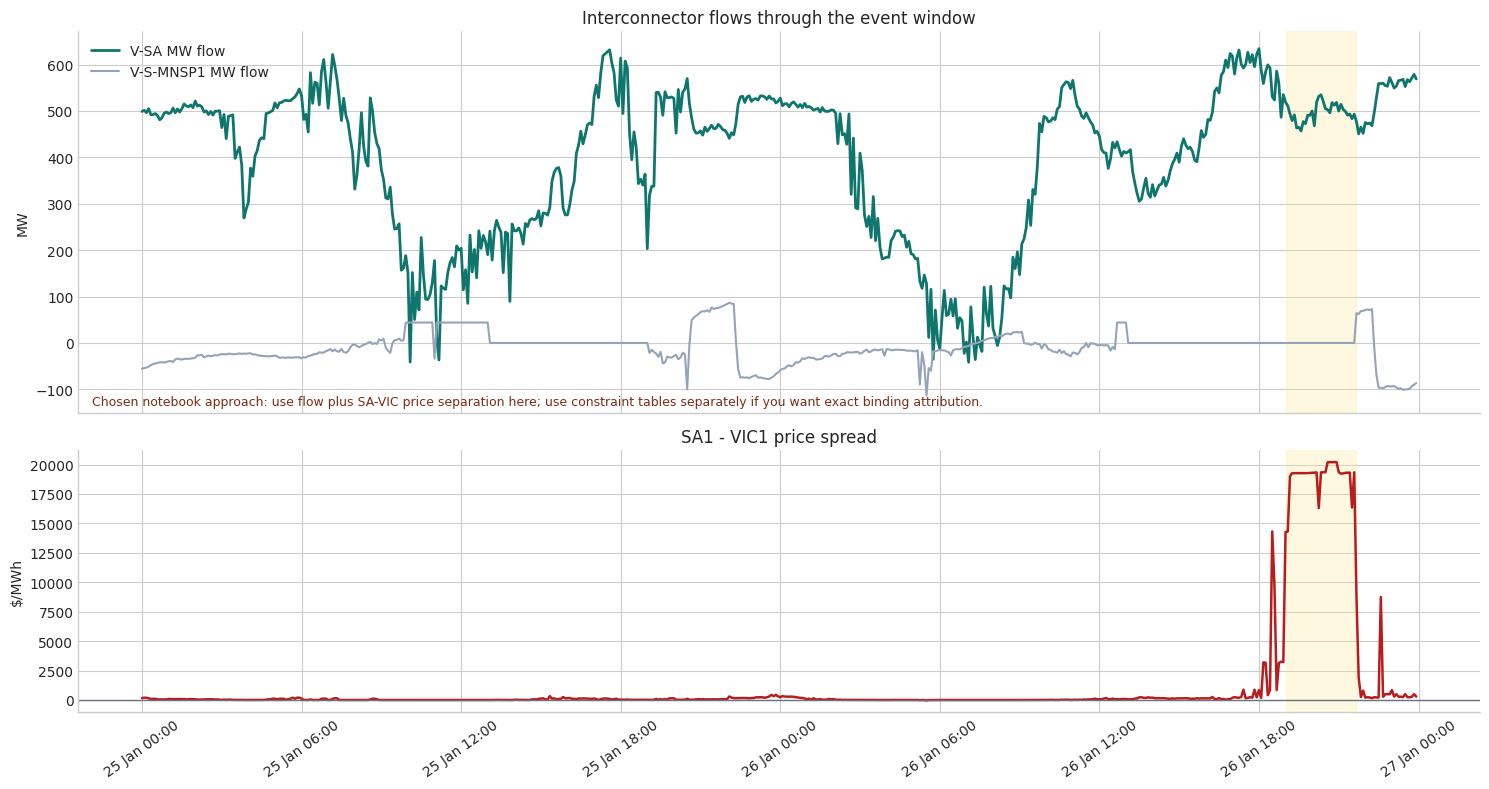

In [9]:
inter_pivot = (
    interconnector.pivot(index='interval_end', on='INTERCONNECTORID', values='MWFLOW')
    .sort('interval_end')
    .join(price_wide.select(['interval_end', 'sa_vic_spread']), on='interval_end', how='left')
    .to_pandas()
)

fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True, height_ratios=[1.6, 1.1])

axes[0].plot(inter_pivot['interval_end'], inter_pivot['V-SA'], label='V-SA MW flow', color='#0f766e', linewidth=2)
if 'V-S-MNSP1' in inter_pivot.columns:
    axes[0].plot(inter_pivot['interval_end'], inter_pivot['V-S-MNSP1'], label='V-S-MNSP1 MW flow', color='#94a3b8', linewidth=1.5)
axes[0].axvspan(event_summary['longest_over_5k_start'], event_summary['longest_over_5k_end'], color='#fde68a', alpha=0.25)
axes[0].set_title('Interconnector flows through the event window')
axes[0].set_ylabel('MW')
axes[0].legend(loc='upper left')
axes[0].text(
    0.01,
    0.02,
    'Chosen notebook approach: use flow plus SA-VIC price separation here; use constraint tables separately if you want exact binding attribution.',
    transform=axes[0].transAxes,
    fontsize=9,
    color='#7c2d12',
)

axes[1].plot(inter_pivot['interval_end'], inter_pivot['sa_vic_spread'], color='#b91c1c', linewidth=1.8)
axes[1].axhline(0, color='#6b7280', linewidth=1)
axes[1].axvspan(event_summary['longest_over_5k_start'], event_summary['longest_over_5k_end'], color='#fde68a', alpha=0.25)
axes[1].set_title('SA1 - VIC1 price spread')
axes[1].set_ylabel('$/MWh')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%d %b %H:%M'))
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()


## Panel 4: Generator Response — Who Dropped, Who Ramped?

This section joins `DISPATCH_UNIT_SCADA` to the registration workbook so the stacked area can be grouped by fuel type and the response table can highlight the biggest unit-level changes between the pre-spike baseline and the peak interval.


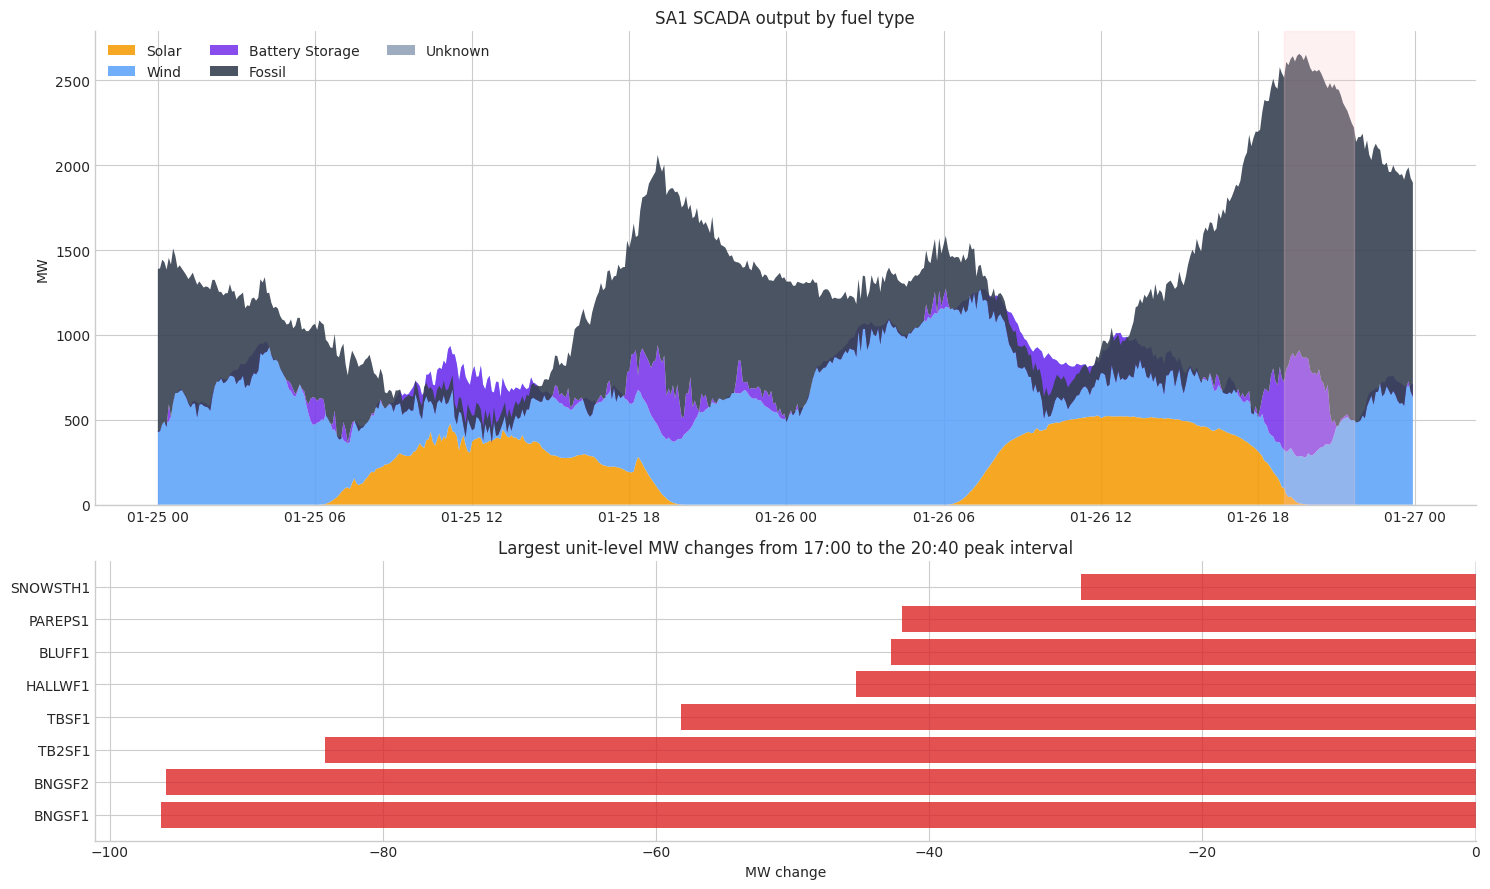

,DUID,station_name,fuel_primary,mw_baseline,mw_peak,mw_change
0,BNGSF1,Bungala One Solar Farm,Solar,96.25000,0.0,-96.25000
1,BNGSF2,Bungala Two Solar Farm,Solar,95.89000,0.0,-95.89000
2,TB2SF1,Tailem Bend 2 Hybrid Renewable Power Station,Solar,84.25636,0.0,-84.25636
3,TBSF1,Tailem Bend Solar Project 1,Solar,58.20000,0.0,-58.20000
4,HALLWF1,Hallett 1 Wind Farm,Wind,45.36000,0.0,-45.36000
5,BLUFF1,The Bluff Wind Farm,Wind,42.80000,0.0,-42.80000
6,PAREPS1,Port Augusta Renewable Energy Park,Solar,41.97000,0.0,-41.97000
7,SNOWSTH1,Snowtown South Wind Farm,Wind,28.89990,0.0,-28.89990


,DUID,station_name,fuel_primary,mw_baseline,mw_peak,mw_change
0,TIB1,Torrens Island BESS,Battery Storage,-6.14000,251.14999,257.28999
1,SNAPPER1,Snapper Point Power Station,Fossil,0.00000,127.09000,127.09000
2,BLYTHB1,Blyth Battery Energy Storage System,Battery Storage,-66.21000,51.20000,117.41000
3,QPS5,Quarantine Power Station,Fossil,0.00000,110.93999,110.93999
4,BOLIVPS1,Bolivar Power Station,Fossil,0.00001,96.74001,96.74000
5,AGLHAL,Hallett Power Station,Fossil,100.38304,178.76987,78.38683
6,PAREPW1,Port Augusta Renewable Energy Park,Wind,0.00000,65.26000,65.26000
7,WPWF,Wattle Point Wind Farm,Wind,8.21000,72.85000,64.64000


In [10]:
BASELINE_TS = pl.datetime(2026, 1, 26, 17, 0)
PEAK_TS = pl.datetime(2026, 1, 26, 20, 40)

fuel_order = ['Solar', 'Wind', 'Battery Storage', 'Fossil', 'Hydro', 'Unknown']
fuel_palette = {
    'Solar': '#f59e0b',
    'Wind': '#60a5fa',
    'Battery Storage': '#7c3aed',
    'Fossil': '#374151',
    'Hydro': '#10b981',
    'Unknown': '#94a3b8',
}

fuel_mix = (
    sa_scada.group_by(['interval_end', 'fuel_primary'])
    .agg(pl.sum('SCADAVALUE').alias('mw'))
    .with_columns(pl.col('fuel_primary').fill_null('Unknown'))
    .sort(['interval_end', 'fuel_primary'])
)

baseline = sa_scada.filter(pl.col('interval_end') == BASELINE_TS).select(['DUID', pl.col('SCADAVALUE').alias('mw_baseline')])
peak = sa_scada.filter(pl.col('interval_end') == PEAK_TS).select(['DUID', pl.col('SCADAVALUE').alias('mw_peak')])

duid_changes = (
    baseline.join(peak, on='DUID', how='full')
    .with_columns([
        pl.coalesce(['mw_baseline', pl.lit(0.0)]).alias('mw_baseline'),
        pl.coalesce(['mw_peak', pl.lit(0.0)]).alias('mw_peak'),
    ])
    .with_columns((pl.col('mw_peak') - pl.col('mw_baseline')).alias('mw_change'))
    .join(
        sa_scada.select(['DUID', 'station_name', 'fuel_primary', 'technology_primary']).unique(),
        on='DUID',
        how='left',
    )
    .sort('mw_change')
)

biggest_drops = duid_changes.head(8)
biggest_ramps = duid_changes.tail(8).sort('mw_change', descending=True)

fuel_mix_pd = fuel_mix.to_pandas()
fuel_mix_pd['fuel_primary'] = pd.Categorical(fuel_mix_pd['fuel_primary'], categories=fuel_order, ordered=True)
fuel_pivot = (
    fuel_mix_pd.pivot(index='interval_end', columns='fuel_primary', values='mw')
    .fillna(0.0)
    .reindex(columns=[c for c in fuel_order if c in fuel_mix_pd['fuel_primary'].dropna().unique()])
)

fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=False, height_ratios=[2.2, 1.3])
axes[0].stackplot(
    fuel_pivot.index,
    [fuel_pivot[col].to_numpy() for col in fuel_pivot.columns],
    labels=list(fuel_pivot.columns),
    colors=[fuel_palette.get(col, '#94a3b8') for col in fuel_pivot.columns],
    alpha=0.9,
)
axes[0].axvspan(event_summary['longest_over_5k_start'], event_summary['longest_over_5k_end'], color='#fecaca', alpha=0.25)
axes[0].set_title('SA1 SCADA output by fuel type')
axes[0].set_ylabel('MW')
axes[0].legend(loc='upper left', ncols=3)

drops_pd = biggest_drops.to_pandas().sort_values('mw_change')
axes[1].barh(drops_pd['DUID'], drops_pd['mw_change'], color='#dc2626', alpha=0.8, label='Largest drops')
axes[1].set_title('Largest unit-level MW changes from 17:00 to the 20:40 peak interval')
axes[1].set_xlabel('MW change')
axes[1].axvline(0, color='#6b7280', linewidth=1)
plt.tight_layout()
plt.show()

display(biggest_drops.select(['DUID', 'station_name', 'fuel_primary', 'mw_baseline', 'mw_peak', 'mw_change']).to_pandas())
display(biggest_ramps.select(['DUID', 'station_name', 'fuel_primary', 'mw_baseline', 'mw_peak', 'mw_change']).to_pandas())


## Panel 5: Heuristic Price Setter View

Without NEMDE `NemPriceSetter` XML or bid stacks, the notebook uses a rough operational heuristic: look at what non-renewable units were actively dispatching during the extreme-price run. If you later want the exact network story, inspect `DISPATCHCONSTRAINT` + `GENCONDATA` for the spike intervals as a manual follow-up rather than building that logic into this notebook.


In [11]:
likely_marginal = (
    sa_scada.filter(
        pl.col('interval_end').is_between(
            event_summary['longest_over_5k_start'],
            event_summary['longest_over_5k_end'],
            closed='both',
        )
        & (pl.col('SCADAVALUE') > 1)
        & pl.col('fuel_primary').is_in(['Fossil', 'Battery Storage'])
    )
    .group_by(['DUID', 'station_name', 'fuel_primary', 'technology_primary'])
    .agg([
        pl.mean('SCADAVALUE').alias('avg_mw'),
        pl.max('SCADAVALUE').alias('max_mw'),
        pl.len().alias('intervals_active'),
    ])
    .sort(['avg_mw', 'max_mw'], descending=True)
)

likely_marginal.head(12).to_pandas()


,DUID,station_name,fuel_primary,technology_primary,avg_mw,max_mw,intervals_active
0,PPCCGT,Pelican Point Power Station,Fossil,Combustion,449.640253,460.78464,33
1,AGLHAL,Hallett Power Station,Fossil,Combustion,177.332026,180.73068,33
2,BARKIPS1,Barker Inlet Power Station,Fossil,Combustion,161.370904,169.20999,33
3,TORRB4,Torrens Island Power Station,Fossil,Combustion,160.121212,194.00000,33
4,TORRB3,Torrens Island Power Station,Fossil,Combustion,159.303030,189.00000,33
5,TORRB2,Torrens Island Power Station,Fossil,Combustion,158.424242,200.00000,33
6,BLYTHB1,Blyth Battery Energy Storage System,Battery Storage,Storage,139.271815,199.14999,22
7,SNAPPER1,Snapper Point Power Station,Fossil,Combustion,122.502422,128.48999,33
8,QPS5,Quarantine Power Station,Fossil,Combustion,106.739090,111.92000,33
9,TEMPB1,Templers Battery Energy Storage System,Battery Storage,Storage,102.650000,108.40000,20


## Trader Briefing Draft

The next cell renders a three-paragraph markdown briefing in the format requested by the notebook brief. It is intentionally editable after you inspect the charts.


In [12]:
biggest_drop = biggest_drops.row(0, named=True)
biggest_ramp = biggest_ramps.row(0, named=True)

briefing = f"""
### Morning Briefing

**What happened.** SA1 spot prices exceeded ${EXTREME_THRESHOLD:,.0f}/MWh for {event_summary['longest_over_5k_intervals']} consecutive dispatch intervals on 2026-01-26, running from {event_summary['longest_over_5k_start']:%H:%M} to {event_summary['longest_over_5k_end']:%H:%M}. The peak price hit ${event_summary['peak_price']:,.0f}/MWh at {event_summary['peak_time']:%H:%M}, while VIC1 stayed comparatively calm with a peak of only ${event_summary['vic_peak_during_run']:,.0f}/MWh during the main extreme-price run.

**Why it happened.** The event was not just a pure demand spike: SA demand reached {event_summary['sa_demand_peak_during_run']:,.0f} MW during the run, but the sharper shift was on the supply side. Solar faded rapidly into the evening, with units such as {biggest_drop['DUID']} ({biggest_drop['station_name']}) rolling off by {abs(biggest_drop['mw_change']):,.0f} MW between 17:00 and the 20:40 peak interval. At the same time, the V-SA interconnector flow stayed elevated between about {event_summary['v_sa_min_flow_during_run']:,.0f} MW and {event_summary['v_sa_max_flow_during_run']:,.0f} MW while the SA-VIC price spread blew out to more than ${event_summary['max_spread']:,.0f}/MWh, consistent with constrained import capability and local scarcity. If you want the exact network binding story, the next manual step is to inspect `DISPATCHCONSTRAINT` + `GENCONDATA` for the spike intervals. The response came from peaking gas and storage, including {biggest_ramp['DUID']} ({biggest_ramp['station_name']}), which ramped by {biggest_ramp['mw_change']:,.0f} MW over the same window.

**What it means.** This is a clean example of South Australian evening scarcity: solar collapses, imports become operationally tight, and local fast-response plant captures the marginal price. For a trader or portfolio manager, the event reinforces the value of SA-positioned batteries, fast-start gas, and demand response during summer ramp hours. If you preserve the raw `DISPATCHINTERCONNECTORRES` columns with `EXPORTLIMIT` and `IMPORTLIMIT`, you can turn this into a direct flow-versus-limit chart. Otherwise, this notebook's simpler flow-plus-spread framing is enough for the case study, and exact constraint attribution can sit beside it as a targeted follow-up rather than part of the core workflow.
"""

display(Markdown(dedent(briefing).strip()))


### Morning Briefing

**What happened.** SA1 spot prices exceeded $5,000/MWh for 33 consecutive dispatch intervals on 2026-01-26, running from 19:00 to 21:40. The peak price hit $20,300/MWh at 20:40, while VIC1 stayed comparatively calm with a peak of only $437/MWh during the main extreme-price run.

**Why it happened.** The event was not just a pure demand spike: SA demand reached 3,140 MW during the run, but the sharper shift was on the supply side. Solar faded rapidly into the evening, with units such as BNGSF1 (Bungala One Solar Farm) rolling off by 96 MW between 17:00 and the 20:40 peak interval. At the same time, the V-SA interconnector flow stayed elevated between about 457 MW and 535 MW while the SA-VIC price spread blew out to more than $20,211/MWh, consistent with constrained import capability and local scarcity. If you want the exact network binding story, the next manual step is to inspect `DISPATCHCONSTRAINT` + `GENCONDATA` for the spike intervals. The response came from peaking gas and storage, including TIB1 (Torrens Island BESS), which ramped by 257 MW over the same window.

**What it means.** This is a clean example of South Australian evening scarcity: solar collapses, imports become operationally tight, and local fast-response plant captures the marginal price. For a trader or portfolio manager, the event reinforces the value of SA-positioned batteries, fast-start gas, and demand response during summer ramp hours. If you preserve the raw `DISPATCHINTERCONNECTORRES` columns with `EXPORTLIMIT` and `IMPORTLIMIT`, you can turn this into a direct flow-versus-limit chart. Otherwise, this notebook's simpler flow-plus-spread framing is enough for the case study, and exact constraint attribution can sit beside it as a targeted follow-up rather than part of the core workflow.